In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [2]:
#data loading
df = pd.read_csv(r'C:\programming\mystery_dungeon_anal\simulation_results.csv')
df = df.sort_values('Spawn_Strategy')
df.shape

(6390, 12)

In [3]:
# 성공 여부만 탐색
df = df[df["Success"]==True]

C:\Users\user\AppData\Local\Temp\ipykernel_18620\3205040075.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')


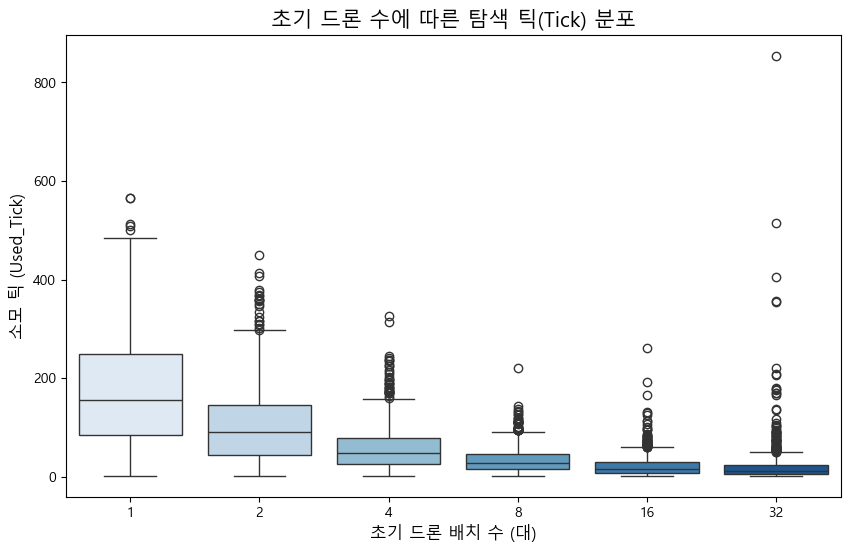

[1단계 ANOVA 검정] P-value: 0.00000

결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.

[2단계 Tukey HSD 사후 검정 표]
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     1      2  -67.6178    0.0  -75.3516   -59.884   True
     1      4 -115.4958    0.0 -123.2296  -107.762   True
     1      8 -138.5427    0.0 -146.2765 -130.8089   True
     1     16 -150.8131    0.0 -158.5469 -143.0794   True
     1     32 -151.7117    0.0 -159.4455 -143.9779   True
     2      4  -47.8779    0.0  -55.6117  -40.1441   True
     2      8  -70.9249    0.0  -78.6587  -63.1911   True
     2     16  -83.1953    0.0  -90.9291  -75.4615   True
     2     32  -84.0939    0.0  -91.8277  -76.3601   True
     4      8  -23.0469    0.0  -30.7807  -15.3132   True
     4     16  -35.3174    0.0  -43.0512  -27.5836   True
     4     32   -36.216    0.0  -43.9498  -28.4822   True
     8     16  -12.2704 0.0001

In [4]:
#box plot
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')
plt.title('초기 드론 수에 따른 탐색 틱(Tick) 분포', fontsize=15)
plt.xlabel('초기 드론 배치 수 (대)', fontsize=12)
plt.ylabel('소모 틱 (Used_Tick)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# 3. 분산 분석 (ANOVA) 및 사후 검정
# ---------------------------------------------------------
groups = [group['Used_Tick'].values for name, group in df.groupby('Spawn_Strategy')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"[1단계 ANOVA 검정] P-value: {p_value:.5f}\n")

if p_value < 0.05:
    print("결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.\n")
    print("="*50)
    print("[2단계 Tukey HSD 사후 검정 표]")
    print("="*50)
    
    # 튜키 검정 실행
    tukey_result = pairwise_tukeyhsd(endog=df['Used_Tick'], 
                                     groups=df['Spawn_Strategy'], 
                                     alpha=0.05)
    print(tukey_result)
else:
    print("결론: 통계적으로 유의미한 성능 차이가 발견되지 않았습니다.")